# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [ ]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/Customer_Personality_Segmentation.csv", sep="\t")

## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

In [ ]:
data.head(1)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

##### **Observations:**

The dataset has 2.240 observations and 29 variables. It has only 3 variables of type object: `Education`, `Marital_Status` and `Dt_Customer`. The rest of the variables are numeric, either integers or floats. Only one variable has missing values: `Income`.

#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


##### **Observations:**

What is the average household income?
*  The average annual `income` is USD 52,247. The standard deviation is very high compare to others values, so annual incomes are quite dispersed. About 75% of customers earn USD 68,522 or less and there is at least one customer with an annual income of USD 666.666 anual incomes, which suggests that the `income` distribution is right-skewed, with most values in the lower range and a few very high incomes.

Others observations:

*   The average birth year of customers is 1969. The youngest customer is 29 years old (born in 1996), and the oldest one appears to be 129 years old, which is quite unlikely. Since the mean and median are very similar, it seems that the `Year_Birth` distribution is approximately symmetric with some outliers.

*   Looking at `Kidhome` and `Teenhome`, they appear very similar. From the median, we can see that 50% of customers have 0 kids or teens at home.

*   The highest spending is on wine and meat, while the lowest is on sweets. This makes sense, as customers seem to have few children.

*   The average number of purchases using deals is 2.32, and 50% of customers have between 1 and 3 purchases. There is at least one customer that use deals on 15 occasions, wich suggest that only a few customers use discounts very frequently. We can also see this in the campaign dummy variables, the highest acceptance was campaign 4, with only 7.4% of customer using it.

*   In the last month, the average of web visits was 5.31. There are also customers with 20 visits, wich shows that there is a lot of variation in customer behaviour on the website.

*   `NumStorePurchases` is the channel with the highest average, 5.79 purchases. It also has the highest standard deviation (3.25), which shows that customer behavior is quite dispersed, with 50% of customers making between 3 and 7 purchases and a maximum of 13. On the other hand, web purchases have a lower average (4.08), with 50% of customers making between 2 and 6 purchases, but there are some customers who really prefer this channel, with 27 purchases.

*   Only 0.9% of customers have made a complain in the last two years.

*   `Z_CostContact` and `Z_Revenue` have the same value for all customers, so they can be excluded from the analysis.










#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [ ]:
pd.DataFrame({
    "Count" : data.isnull().sum()[data.isnull().sum() > 0],

    "Percentage" : (data.isnull().sum()[data.isnull().sum() > 0] / data.shape[0]) * 100})


,Count,Percentage
Income,24,1.071429


##### **Observations:**
Around 1.071% of observations with missing values in `income`.
We can use the `Education` variable to group the incomes by education  and then impute the median for each group in the rows where income is missing.



In [ ]:
data.loc[data['Income'].isnull()==True]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,5,6,0,2,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,1,3,3,263,362,0,27,0,0,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,11,50,3,2,39,1,1,3,4,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,5,48,6,10,7,3,2,1,4,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,3,22,2,2,6,2,2,0,3,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,3,43,17,4,17,3,3,0,3,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,42,192,49,37,53,12,7,2,8,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,0,8,2,0,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,37,359,98,28,18,1,2,4,8,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,0,27,10,0,15,3,6,1,7,6,0,0,0,0,0,0,3,11,0


In [ ]:
data.groupby('Education')['Income'].median()

,Income
Education,
2n Cycle,46805.0
Basic,20744.0
Graduation,52028.5
Master,50943.0
PhD,55212.0


In [ ]:
data.groupby('Education')['Income'].transform('median')

,Income
0,52028.5
1,52028.5
2,52028.5
3,52028.5
4,55212.0
...,...
2235,52028.5
2236,55212.0
2237,52028.5
2238,50943.0


In [ ]:
data['Income'] = data['Income'].fillna(value=data.groupby('Education')['Income'].transform('median'))

In [ ]:
# Check if the imputation is correct
data[data['ID']==1994]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,52028.5,1,0,15-11-2013,11,5,5,6,0,2,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0


#### **Question 4**: Are there any duplicates in the data?

In [ ]:
pd.DataFrame({
    "Count" : data.duplicated().sum()[data.duplicated().sum() > 0],

    "Percentage" : (data.duplicated().sum()[data.duplicated().sum() > 0] / data.shape[0]) * 100})

,Count,Percentage


In [ ]:
data_without_ID= data.drop(columns=['ID'])
pd.DataFrame({
    "Count" : data_without_ID.duplicated().sum()[data_without_ID.duplicated().sum() > 0],

    "Percentage" : (data_without_ID.duplicated().sum()[data_without_ID.duplicated().sum() > 0] / data_without_ID.shape[0]) * 100})

,Count,Percentage
0,182,8.125


##### **Observations:**

The dataset does not contain any duplicate customer IDs.
However, when checking the dataset without the ID variable, there are 182 customers with identical values across all other variables. This could indicate a potential data quality issue.

## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

Year_Birth
Skew : -0.35


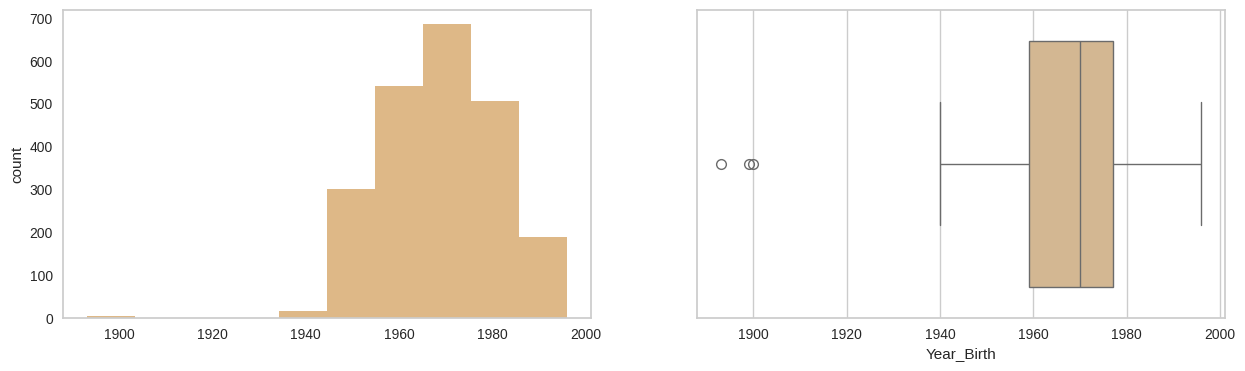

Income
Skew : 6.8


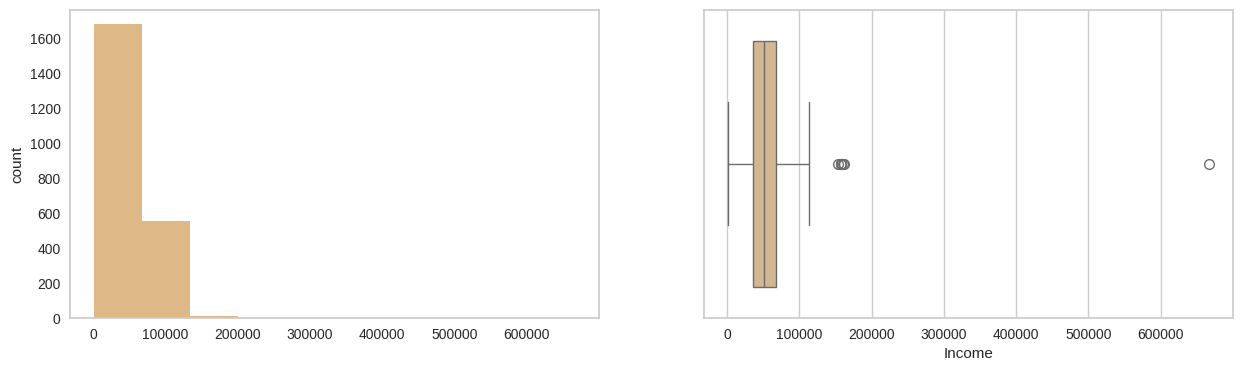

Kidhome
Skew : 0.64


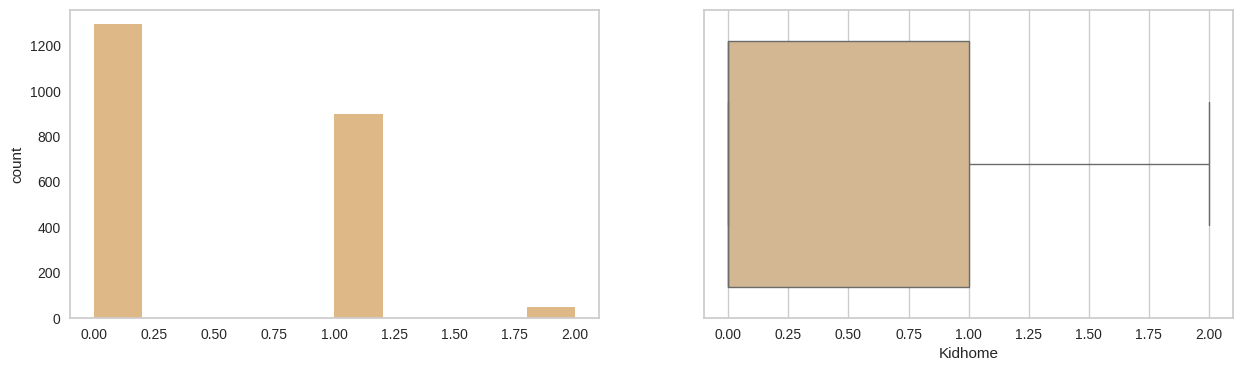

Teenhome
Skew : 0.41


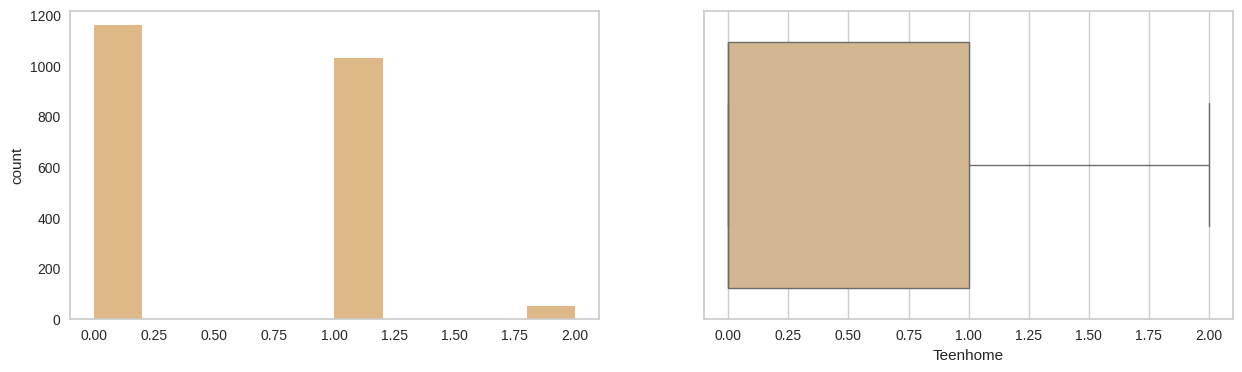

Recency
Skew : -0.0


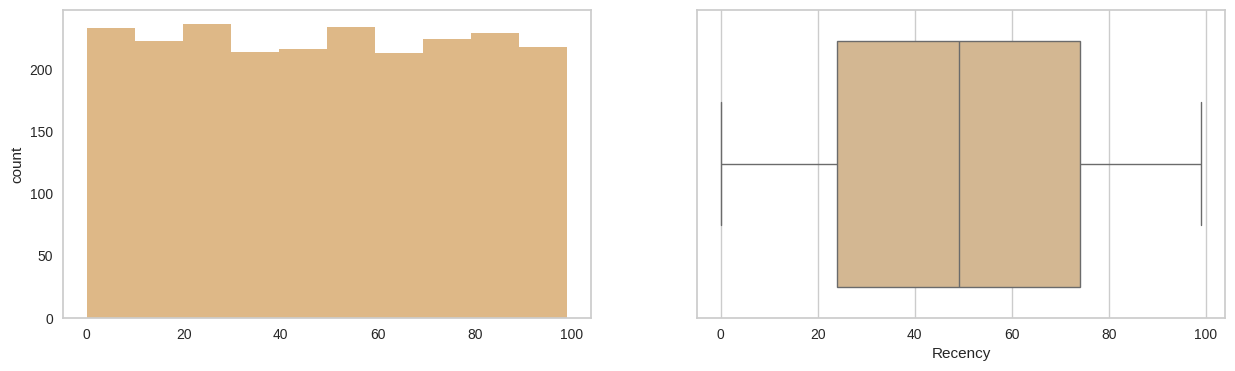

MntWines
Skew : 1.18


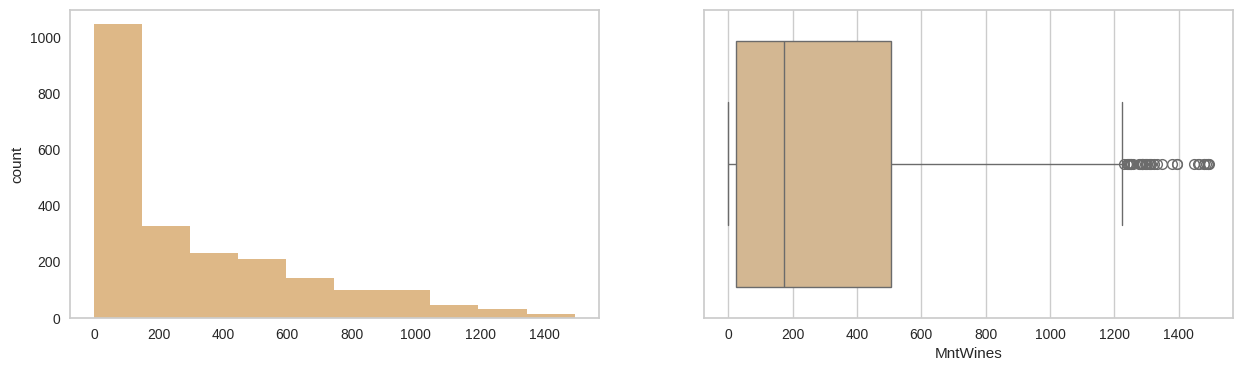

MntFruits
Skew : 2.1


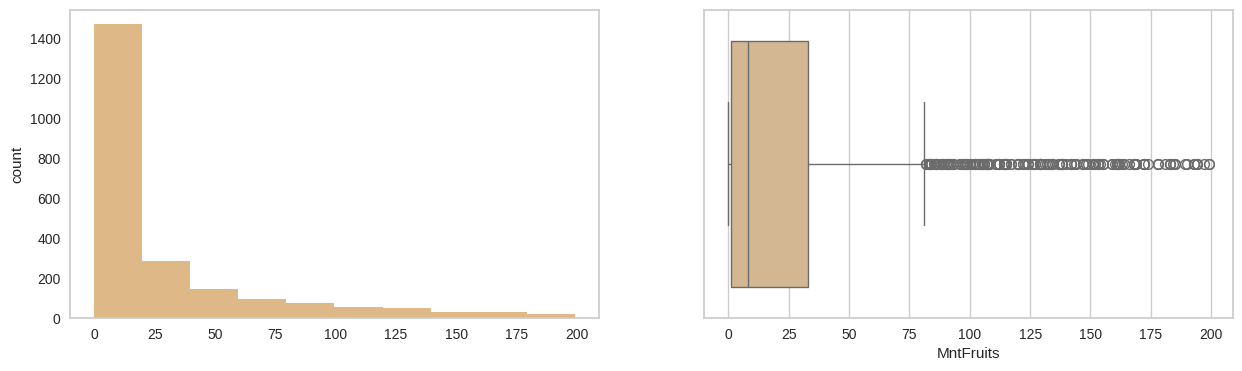

MntMeatProducts
Skew : 2.08


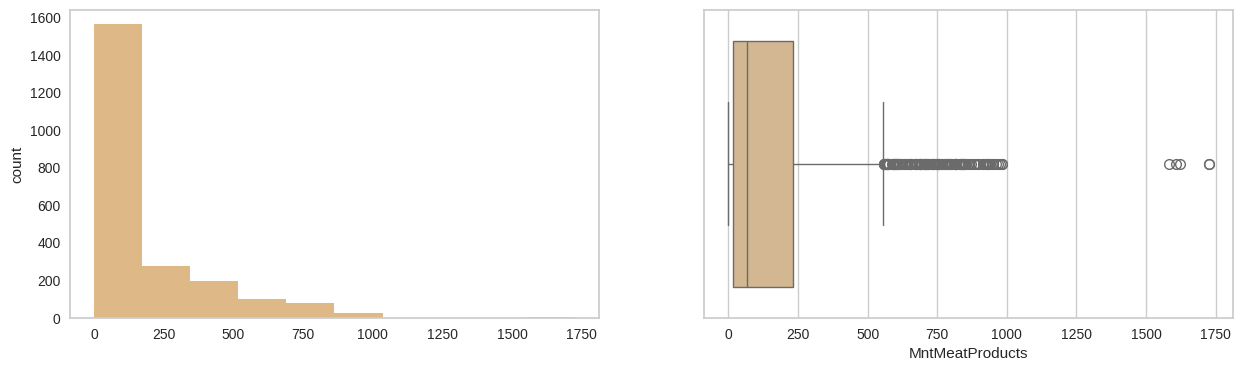

MntFishProducts
Skew : 1.92


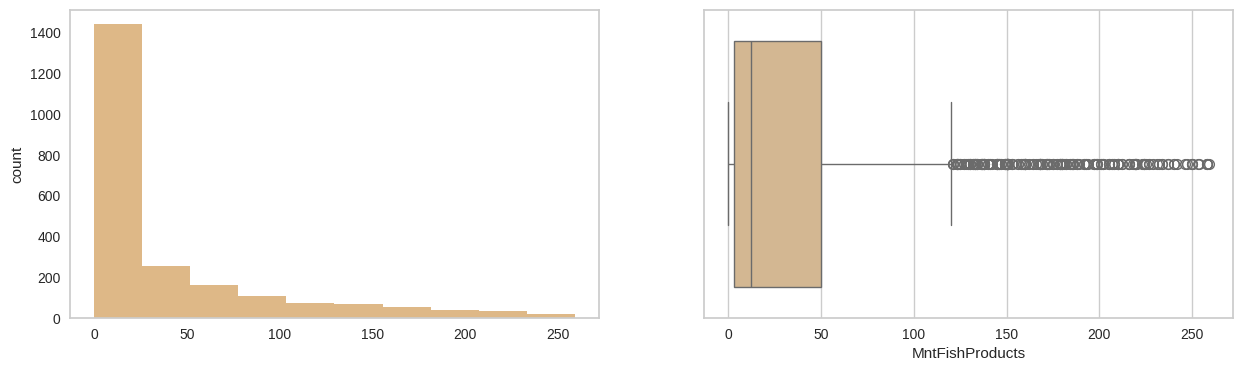

MntSweetProducts
Skew : 2.14


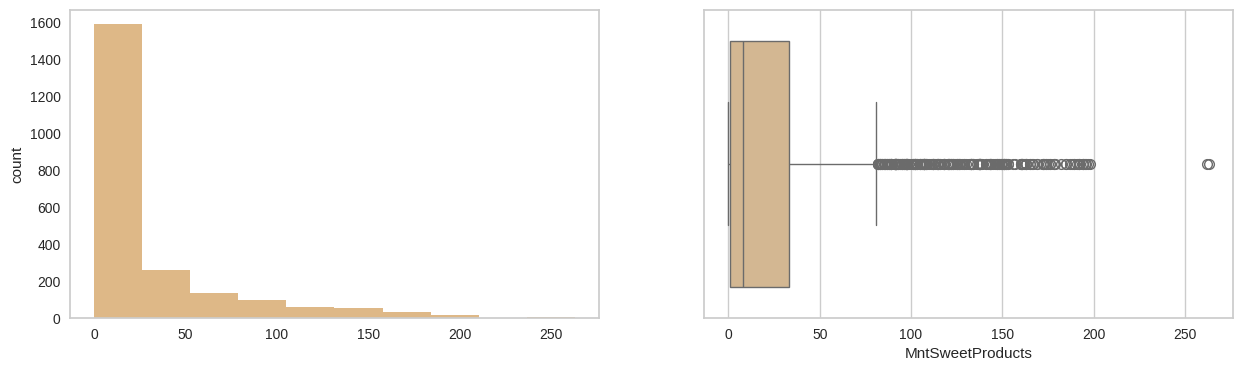

MntGoldProds
Skew : 1.89


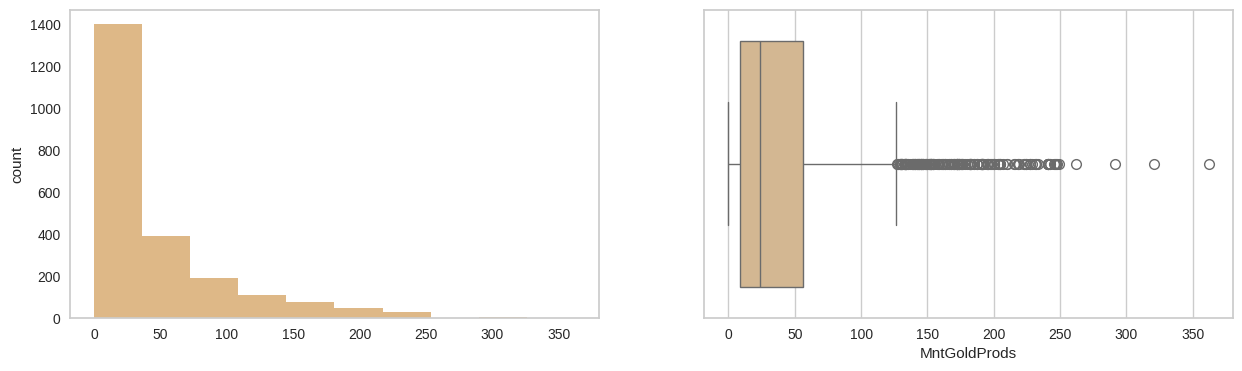

NumDealsPurchases
Skew : 2.42


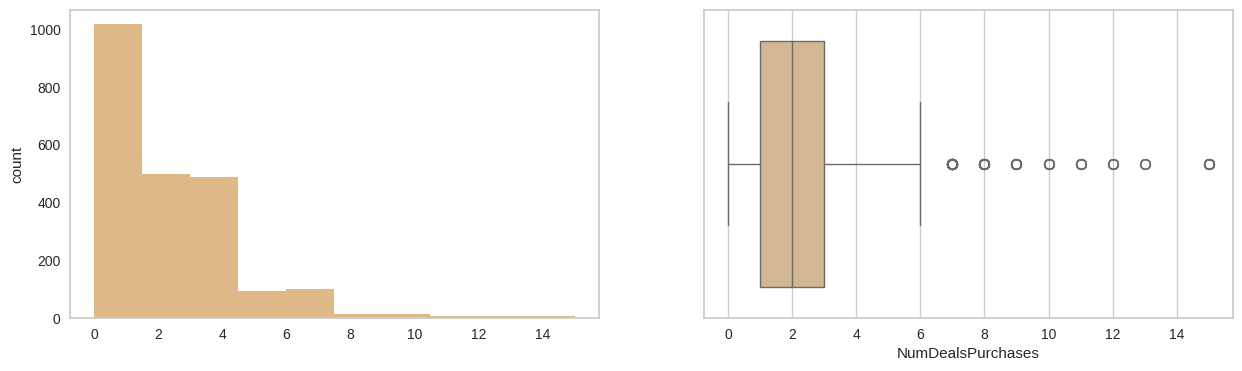

NumWebPurchases
Skew : 1.38


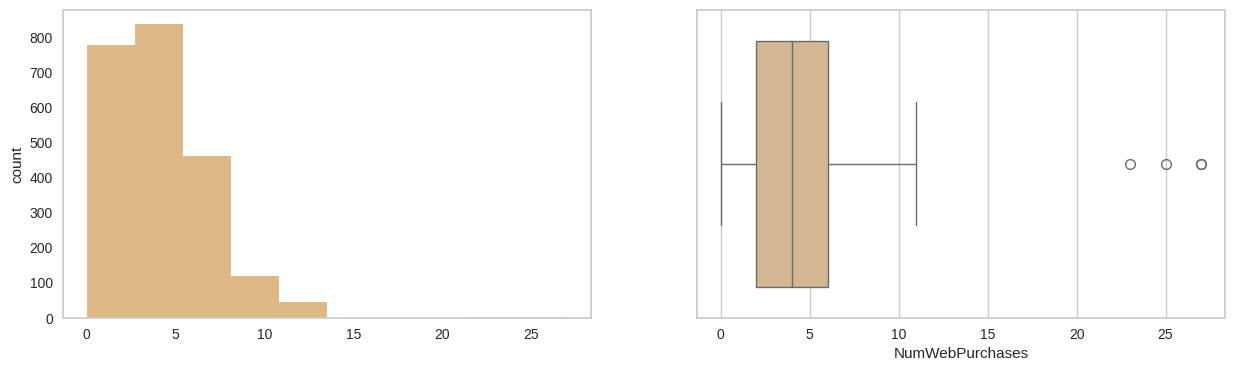

NumCatalogPurchases
Skew : 1.88


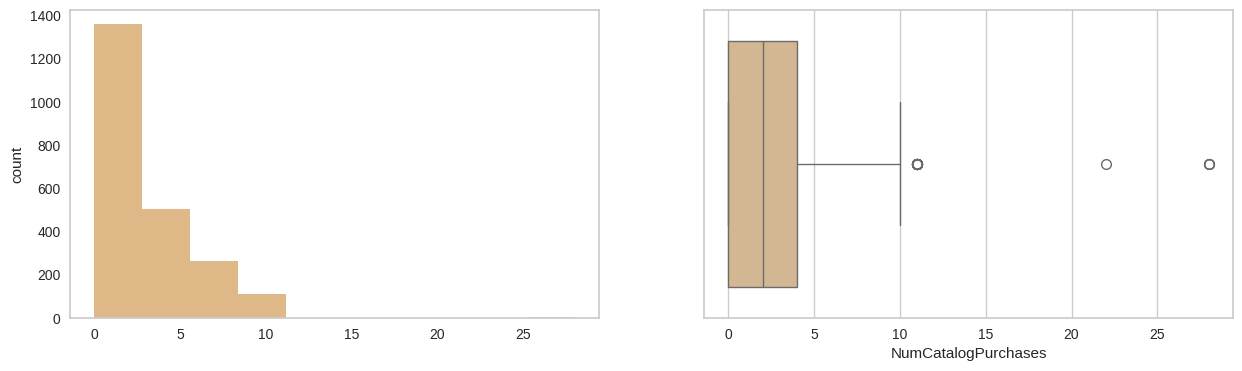

NumStorePurchases
Skew : 0.7


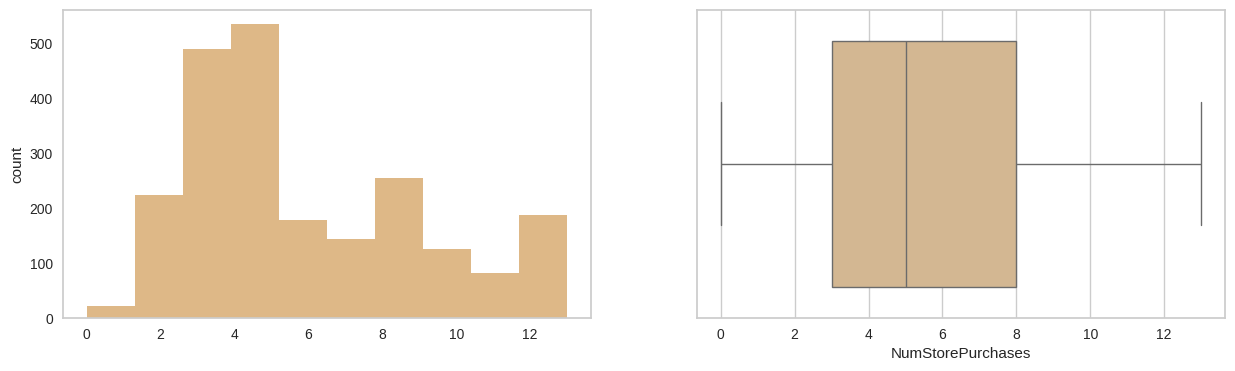

NumWebVisitsMonth
Skew : 0.21


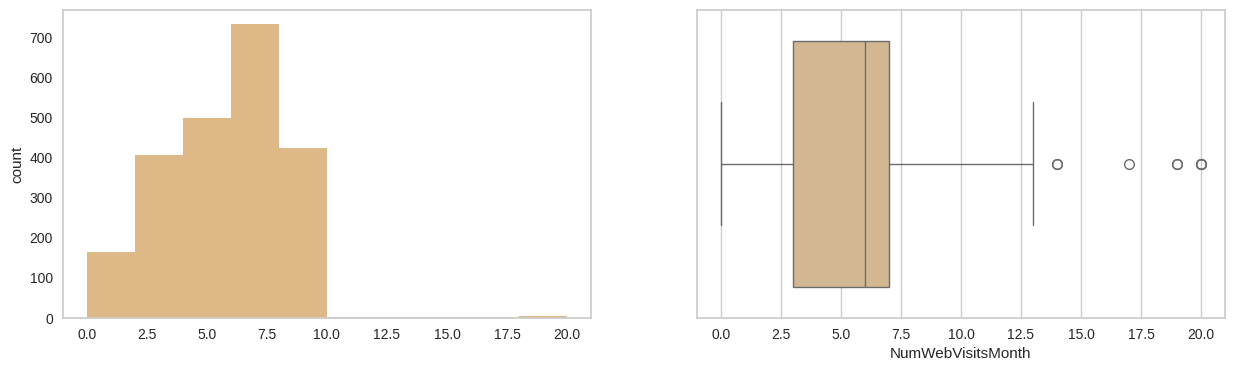

In [ ]:
data_numeric = data.select_dtypes(include=np.number)
data_numeric = data_numeric.drop(columns=['ID','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','AcceptedCmp2','AcceptedCmp1','Complain','Response','Z_Revenue','Z_CostContact'])

for col in data_numeric.columns:
    print(col)
    print('Skew :',round(data_numeric[col].skew(),2))
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    data_numeric[col].hist(bins=10, grid=False, color='burlywood')
    plt.ylabel('count')
    plt.subplot(1,2,2)
    sns.boxplot(x=data_numeric[col], color='burlywood')
    plt.show()

##### **Observations:**



*   `Year_Birth` has the most values concentrated between 1960 and 1980. The distributions is almost simetric, with a very small skew (-0.35), and three outliers where the year is lower than 1900. These customers would be over 125 years old, wich is probably a data issue.

*   `Income` has an outlier with more than USD 600,000 per year. 50% of customers earn USD 50,000 or less. This could be another imputation error.

*   Most customers don't have any children. Among those who do, having one child is more common than having two. The same applies to teenagers: most customers do not have any at home, and among those who do, having one is the most frequent.

*   The distribution of Recency is quite uniform, with 50% of customers having a recency of 50 days or less. There are no outliers, and the boxplot is very symmetric. This variable does not seem to differentiate between customers, so I decided to remove it from the model.

* The spending amounts across all product categories are very similar. They are concentrated at lower values and contain many outliers, resulting in a highly dispersed and right skewed distribution.

* `NumDealsPurchases` has a skew 2.42. From the boxplot, we can see at least 8 outliers. The distribution is right skewed.

*   `NumStorePurchases` has a lowest skew (0.7) and does not have outliers.  `NumWebPurchases` (skew: 1.38) and `NumCatalogPurchases` (skew 1.88) are more dispersed. All of them have a right skewed distribution.







##### **Outliers analysis:**

In [ ]:
#Check outliers year_birth
data[data['Year_Birth']<=1900]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,26-09-2013,99,15,6,8,7,4,25,1,2,1,2,5,0,0,0,0,0,1,3,11,0
239,11004,1893,2n Cycle,Single,60182.0,0,1,17-05-2014,23,8,0,5,7,0,2,1,1,0,2,4,0,0,0,0,0,0,3,11,0
339,1150,1899,PhD,Together,83532.0,0,0,26-09-2013,36,755,144,562,104,64,224,1,4,6,4,1,0,0,1,0,0,0,3,11,0


K-Means is sensitive to outliers. I prefer to drop these three customers because their ages are very unusual, and it is possible that they are typing errors.


In [ ]:
data.drop(data[data['Year_Birth'] <= 1900].index, inplace=True)
data = data.reset_index(drop=True)

In [ ]:
#Check outliers income
data[data['Income']>100000]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
124,7215,1983,Graduation,Single,101970.0,0,0,12-03-2013,69,722,27,102,44,72,168,0,6,8,13,2,0,1,1,1,0,0,3,11,1
164,8475,1973,PhD,Married,157243.0,0,1,01-03-2014,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,0,0,0,0,3,11,0
202,2798,1977,PhD,Together,102160.0,0,0,02-11-2012,54,763,29,138,76,176,58,0,7,9,10,4,0,1,1,1,0,0,3,11,1
250,10089,1974,Graduation,Divorced,102692.0,0,0,05-04-2013,5,168,148,444,32,172,148,1,6,9,13,2,0,1,1,1,1,0,3,11,1
614,1503,1976,PhD,Together,162397.0,1,1,03-06-2013,31,85,1,16,2,1,2,0,0,0,1,1,0,0,0,0,0,0,3,11,0
643,4611,1970,Graduation,Together,105471.0,0,0,21-01-2013,36,1009,181,104,202,21,207,0,9,8,13,3,0,0,1,1,0,0,3,11,1
652,5555,1975,Graduation,Divorced,153924.0,0,0,07-02-2014,81,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,3,11,0
684,1501,1982,PhD,Married,160803.0,0,0,04-08-2012,21,55,16,1622,17,3,4,15,0,28,1,0,0,0,0,0,0,0,3,11,0
1297,5336,1971,Master,Together,157733.0,1,0,04-06-2013,37,39,1,9,2,0,8,0,1,0,1,1,0,0,0,0,0,0,3,11,0
1650,4931,1977,Graduation,Together,157146.0,0,0,29-04-2013,13,1,0,1725,2,1,1,0,0,28,0,1,0,0,0,0,0,0,3,11,0


Customer ID 9432 has an unusually high income of 666,666, while the other income outliers are more similar to each other. In some datasets, values like this may represent issues with the data.

In [ ]:
data.drop(data[data['Income'] > 600000].index, inplace=True)
data = data.reset_index(drop=True)

<Axes: xlabel='Income', ylabel='Count'>

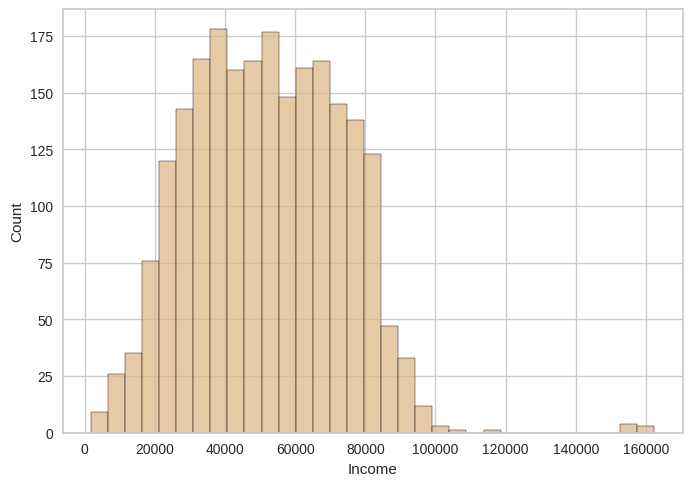

In [ ]:
sns.histplot(x=data['Income'], color='burlywood')

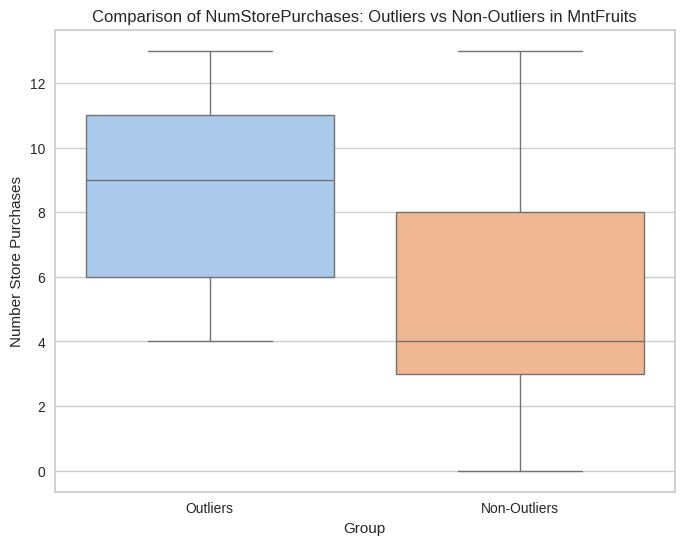

In [ ]:
#Check outliers amount spent

Q1 = data['MntFruits'].quantile(0.25)
Q3 = data['MntFruits'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = data[data['MntFruits'] > upper_bound]
outliers_no = data[data['MntFruits'] <= upper_bound]

outliers['Group'] = 'Outliers'
outliers_no['Group'] = 'Non-Outliers'

df_plot = pd.concat([outliers, outliers_no])

plt.figure(figsize=(8,6))
sns.boxplot(x='Group', y='NumStorePurchases', data=df_plot, palette='pastel')
plt.title('Comparison of NumStorePurchases: Outliers vs Non-Outliers in MntFruits')
plt.ylabel('Number Store Purchases')
plt.xlabel('Group')
plt.show()




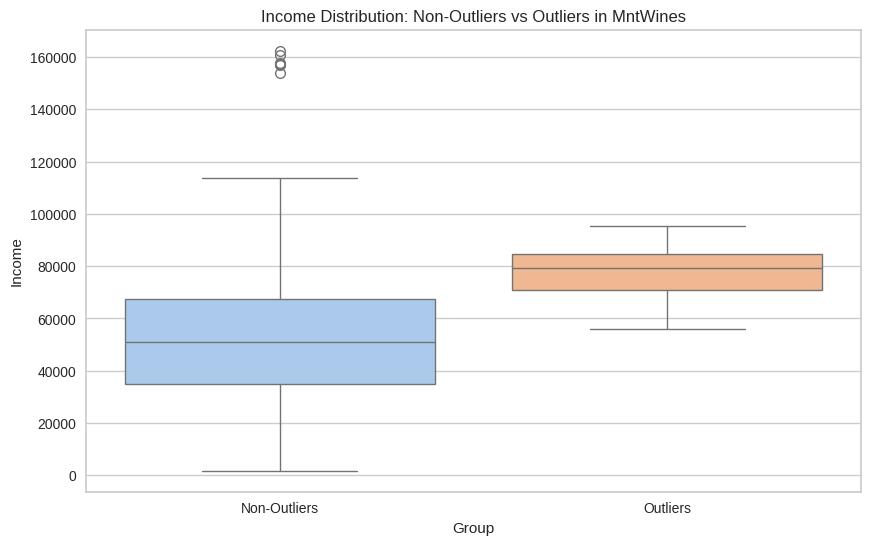

In [ ]:

Non_outliers_MntWines = data[data['MntWines'] <= 1200]
outliers_MntWines = data[data['MntWines'] > 1200]


Non_outliers_MntWines = Non_outliers_MntWines.dropna(subset=['Income'])
outliers_MntWines = outliers_MntWines.dropna(subset=['Income'])

Non_outliers_MntWines['Group'] = 'Non-Outliers'
outliers_MntWines['Group'] = 'Outliers'

df_plot = pd.concat([Non_outliers_MntWines, outliers_MntWines])

plt.figure(figsize=(10,6))
sns.boxplot(x='Group', y='Income', data=df_plot, palette='pastel')
plt.title('Income Distribution: Non-Outliers vs Outliers in MntWines')
plt.ylabel('Income')
plt.show()






We can observe that the amounts spent on different products, such as fruits or wine, may be correlated with other customer features. For example, customers who spend more on wine tend to have higher average incomes than those who spend less. Similarly, customers who buy more fruits tend to make more store purchases on average.

These extreme values should not be deleted or modified, as they reflect genuine differences in customer behavior.

##### Object or dummy values #####



Marital_Status


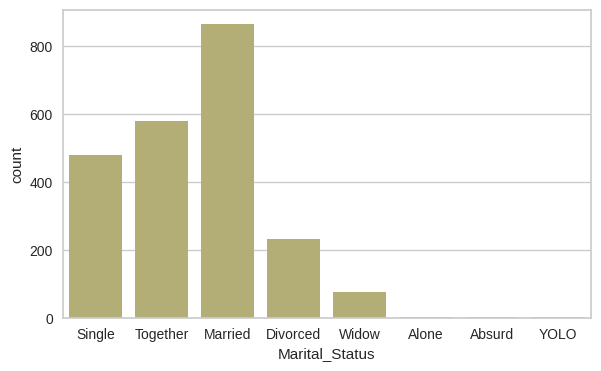

Education


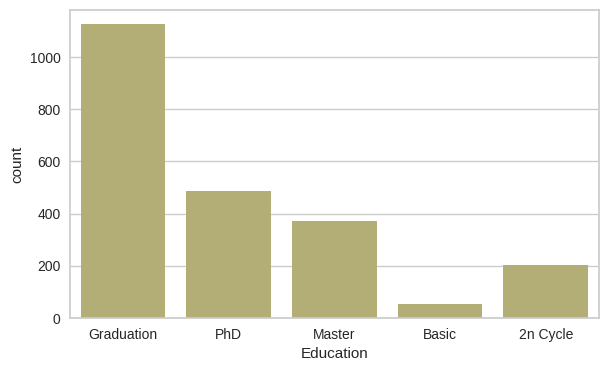

AcceptedCmp3


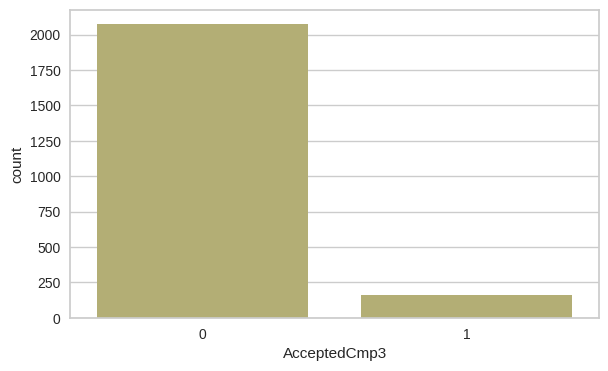

AcceptedCmp4


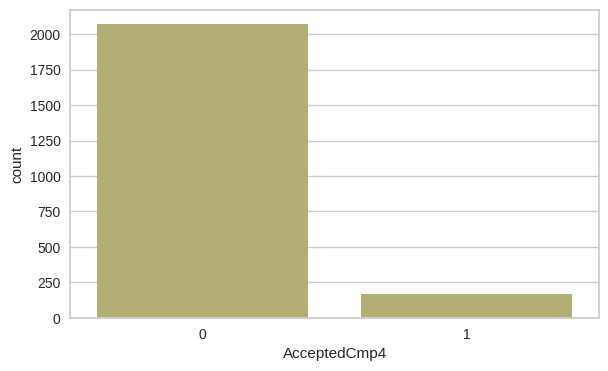

AcceptedCmp5


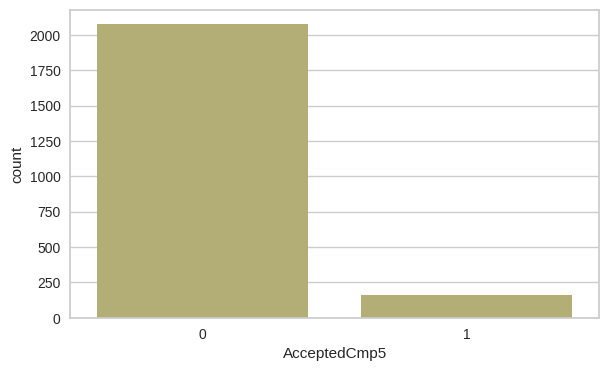

AcceptedCmp2


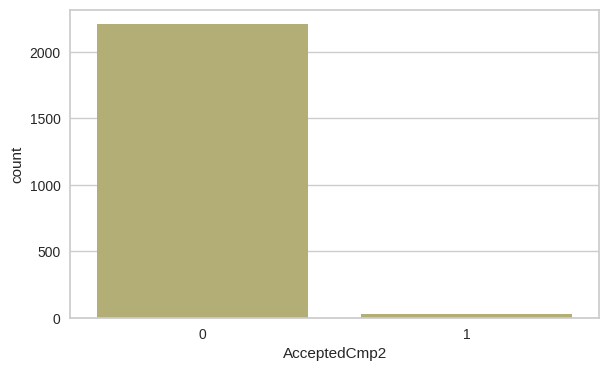

AcceptedCmp1


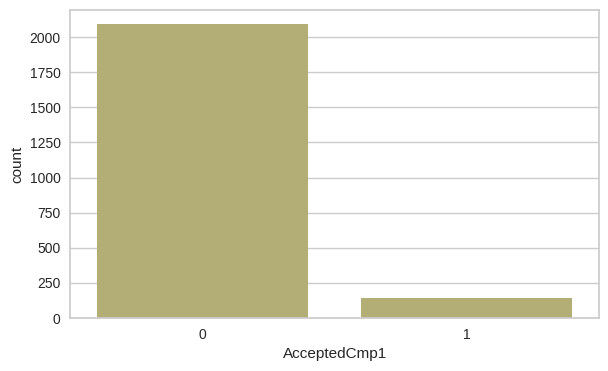

Complain


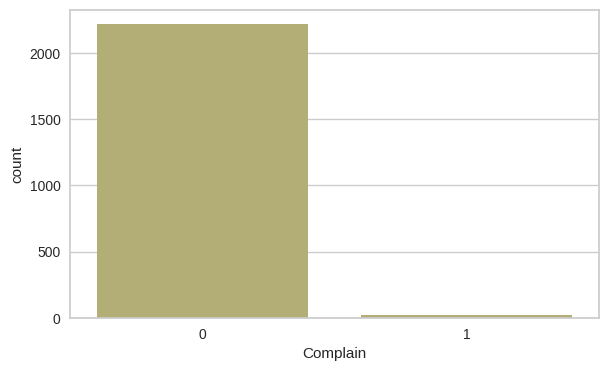

Response


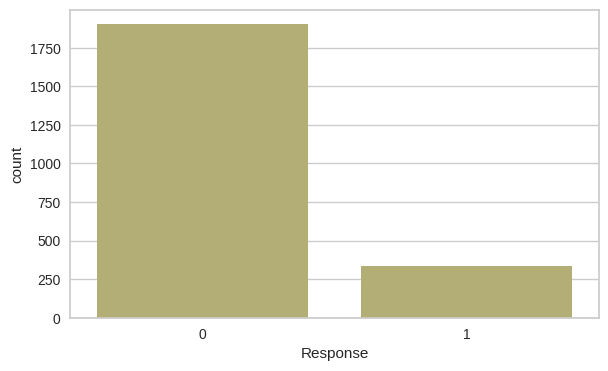

In [ ]:
data_categoric = data[['Marital_Status', 'Education', 'AcceptedCmp3', 'AcceptedCmp4',
                       'AcceptedCmp5', 'AcceptedCmp2', 'AcceptedCmp1', 'Complain', 'Response']]

for col in data_categoric.columns:
    print(col)
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    sns.countplot(data=data_categoric, x=col, color='darkkhaki')
    plt.show()

##### **Observations:**



*   Married status is the most frequent category in the dataset, followed by Single and Together.
*   In education the most frequent is Graduation, followed by PhD and Master, while Basic education has the lowest frequency.
* All de dummy variables have a very low frequency of 1.

None of the categorical or dummy variables seem to represent distinct groups also K means works better with numeric I decide remove them from the model.


In [ ]:
df = data.drop(columns=['Marital_Status', 'Education', 'AcceptedCmp3', 'AcceptedCmp4',
                       'AcceptedCmp5', 'AcceptedCmp2', 'AcceptedCmp1', 'Complain', 'Response', 'Recency', 'ID','Z_Revenue','Z_CostContact','Dt_Customer'])

### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

In [ ]:
df.shape

(2236, 15)

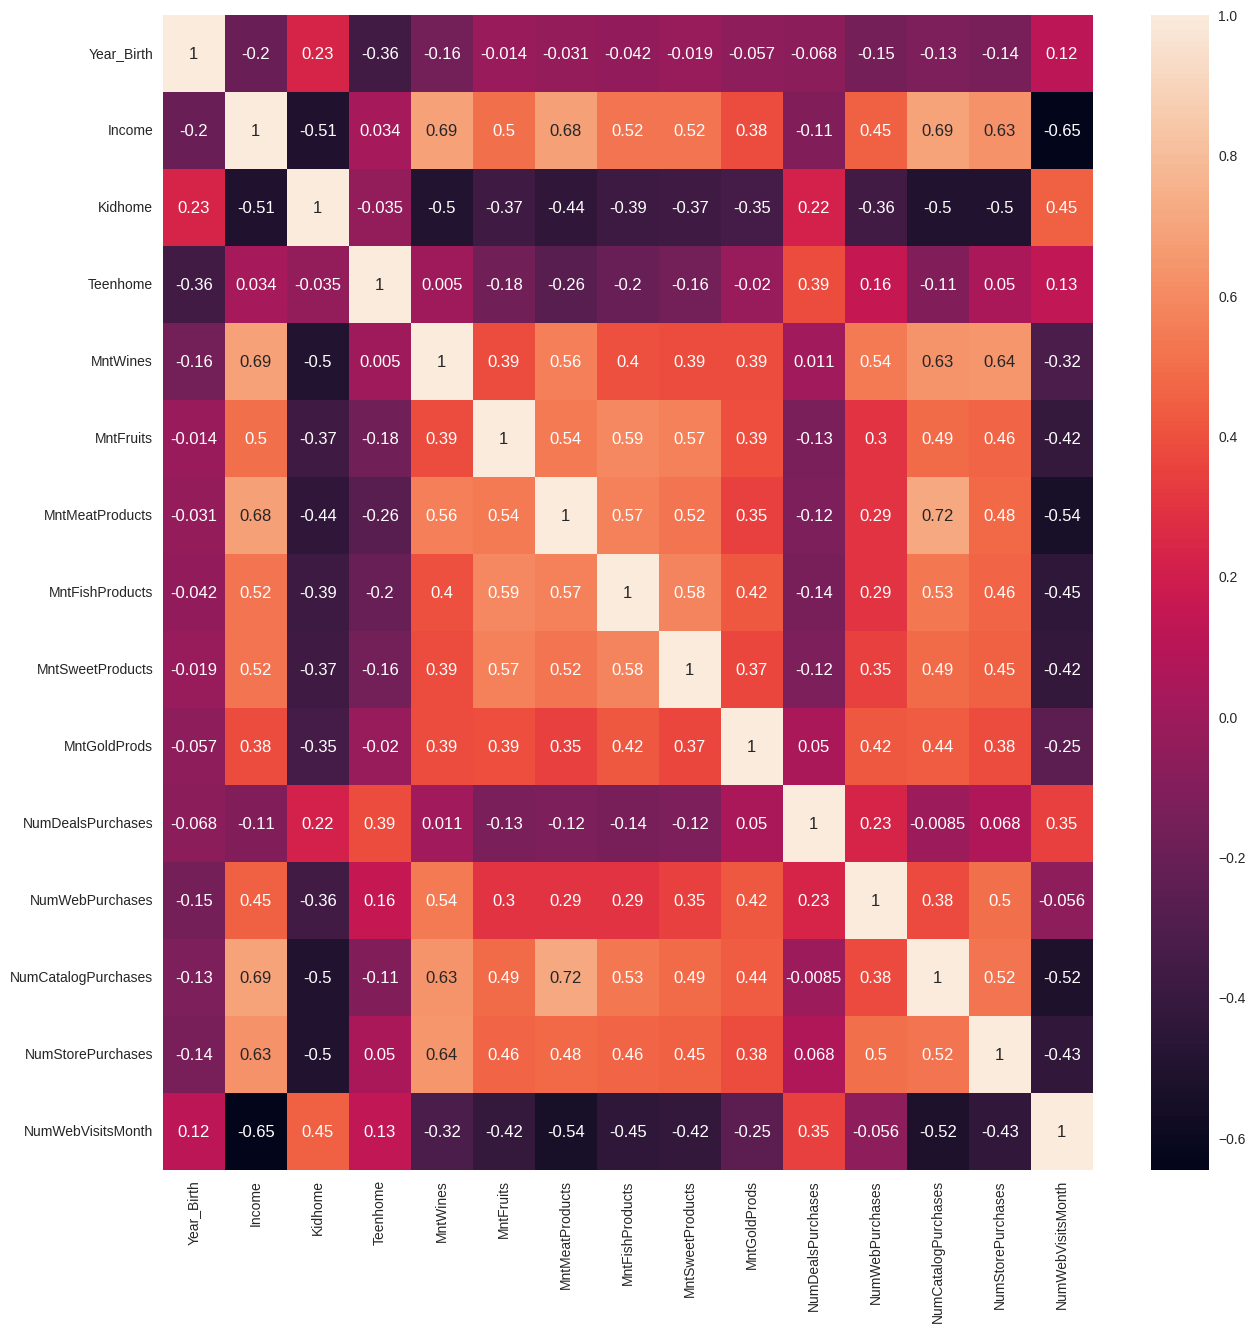

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot=True)
plt.show()

##### **Observations:**
*  No single value shows a strong correlation with the others.

*  MntWines, MntMeatProducts, NumCatalogPurchases, and NumStorePurchases have a weak positive correlation with income. NumWebVisitsMonth has a weak negative correlation with income, suggesting that customers with higher income may tend to spend more on these products and visit the store more frequently.

*  The variable pair with the strongest correlation is MntMeatProducts and NumCatalogPurchases. The relationship is positive: customers tend to buy more meat products when purchasing through the catalog. This may indicate that the catalog provides information that gives customers more confidence to buy meat.

*  NumWebVisitsMonth is not correlated with NumWebPurchases, indicating that more visits do not necessarily lead to more purchases.





## **K-means Clustering**

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

In [ ]:
scaler=StandardScaler()
data_scaled=pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
data_scaled

,Year_Birth,Income,Kidhome,Teenhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,-1.016868,0.288712,-0.824939,-0.930615,0.983228,1.554170,1.679746,2.461068,1.475396,0.845669,0.348738,1.407639,2.509801,-0.552429,0.692865
1,-1.273264,-0.262203,1.032627,0.905974,-0.871064,-0.636431,-0.713455,-0.650414,-0.631638,-0.729742,-0.168700,-1.110921,-0.568970,-1.167738,-0.131421
2,-0.333146,0.918149,-0.824939,-0.930615,0.362159,0.572177,-0.177201,1.344595,-0.147262,-0.038098,-0.686137,1.407639,-0.226884,1.293496,-0.543564
3,1.290693,-1.182324,1.032627,-0.930615,-0.871064,-0.560893,-0.651409,-0.503991,-0.583200,-0.748954,-0.168700,-0.751127,-0.911056,-0.552429,0.280722
4,1.034298,0.295952,1.032627,-0.930615,-0.389661,0.421101,-0.217088,0.154911,-0.001950,-0.556831,1.383614,0.328256,0.115201,0.062879,-0.131421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,-0.162216,0.432817,-0.824939,0.905974,1.203128,0.421101,0.066551,0.081700,2.201960,3.900428,-0.168700,1.767433,0.115201,-0.552429,-0.131421
2232,-1.956986,0.563188,2.890194,0.905974,0.302727,-0.661610,-0.607091,-0.687019,-0.655857,-0.691317,2.418490,1.407639,-0.226884,-0.244775,0.692865
2233,1.034298,0.234667,-0.824939,-0.930615,1.794481,0.546997,0.221666,-0.101329,-0.365231,-0.383920,-0.686137,-0.751127,0.115201,2.216459,0.280722
2234,-1.102333,0.807536,-0.824939,0.905974,0.368102,0.093769,0.208371,0.777208,0.070707,0.326936,-0.168700,0.688050,0.799373,1.293496,-0.955707


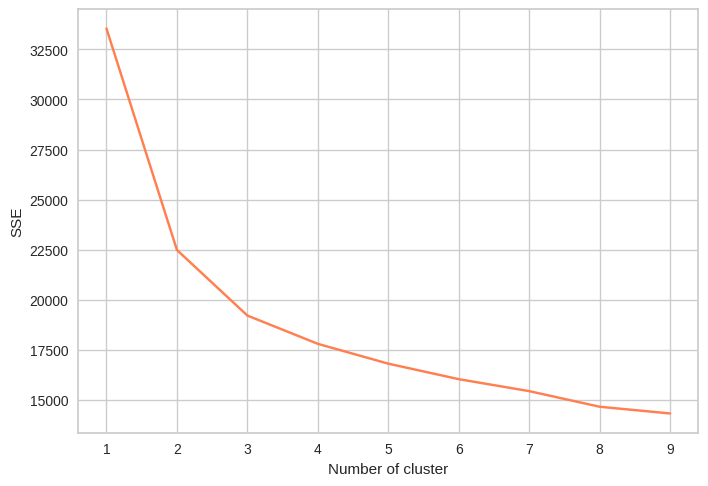

In [ ]:

sse = {}
for k in range(1, 10):
    kmeans = KMeans(n_clusters = k, random_state = 1).fit(data_scaled)
    sse[k] = kmeans.inertia_

plt.figure()
plt.plot(list(sse.keys()), list(sse.values()), 'bx-', color='coral')
plt.xlabel("Number of cluster")
plt.ylabel("SSE")
plt.show()

##### **Observations:**

Using the elbow method, we selected the number of clusters at the point where the curve starts to flatten. In this case, the elbow method suggests that choosing 2 clusters is preferable.

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

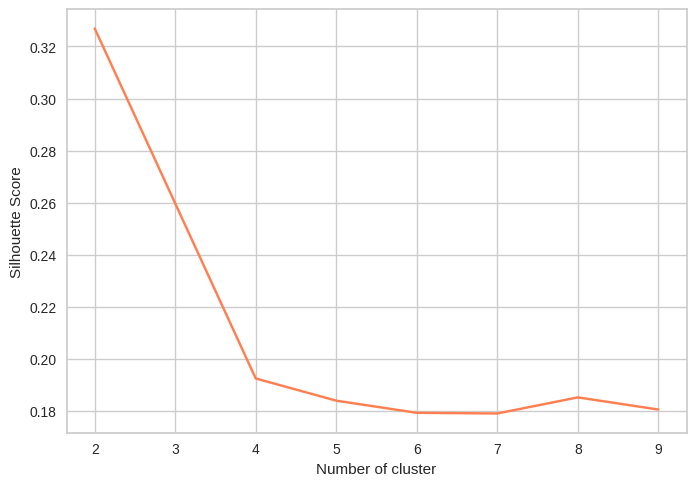

In [ ]:

sc = {}

for k in range(2, 10):
    kmeans = KMeans(n_clusters = k, random_state = 1).fit(data_scaled)

    labels = kmeans.predict(data_scaled)

    sc[k] = silhouette_score(data_scaled, labels)

plt.figure()

plt.plot(list(sc.keys()), list(sc.values()), 'bx-', color='coral')

plt.xlabel("Number of cluster")

plt.ylabel("Silhouette Score")

plt.show()

##### **Observations:**

In the Silhouette Score method, we selected the number of clusters with the highest score, because it means that the clusters are more cohesive and well separated from each other.
In this case, both the Elbow method and the Silhouette Score suggest the same number of clusters: 2.



#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [ ]:
kmeans = KMeans(n_clusters = 2, random_state = 42)

kmeans.fit(data_scaled)

KMeans(n_clusters=2, random_state=42)

##### **Observations:**

The model completed in less than one second.

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

In [ ]:
data_scaled_copy = data_scaled.copy()
data_scaled_copy['KMeans_Labels'] = kmeans.labels_

df['KMeans_Labels'] = kmeans.labels_

In [ ]:
df['KMeans_Labels'].value_counts()

,count
KMeans_Labels,
1,1302
0,934


We can see that Cluster 0 contains 934 customers, while Cluster 1 contains 1.302 customers.

In [ ]:
df.columns

Index(['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'KMeans_Labels'],
      dtype='object')

In [ ]:
original_features = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

num_cols = original_features + ['KMeans_Labels']

mean = df[num_cols].groupby('KMeans_Labels').mean()
median = df[num_cols].groupby('KMeans_Labels').median()

df_kmeans = pd.concat([mean, median], axis=0)

clusters = mean.index.tolist()
new_index = [f"group_{c} Mean" for c in clusters] + [f"group_{c} Median" for c in clusters]
df_kmeans.index = new_index

df_kmeans[original_features].T

,group_0 Mean,group_1 Mean,group_0 Median,group_1 Median
Year_Birth,1966.989293,1970.267281,1967.0,1972.0
Income,70804.454497,38437.044547,70745.0,38177.0
Kidhome,0.068522,0.713518,0.0,1.0
Teenhome,0.444325,0.551459,0.0,1.0
MntWines,592.685225,97.128264,549.5,32.0
MntFruits,54.498929,6.029954,38.0,3.0
MntMeatProducts,350.483940,35.347926,282.0,19.0
MntFishProducts,77.371520,8.960061,60.5,4.0
MntSweetProducts,56.395075,6.051459,41.0,3.0
MntGoldProds,74.576017,22.036866,54.0,12.0


Year_Birth
Skew: KMeans_Labels
0    0.13
1   -0.23
Name: Year_Birth, dtype: float64


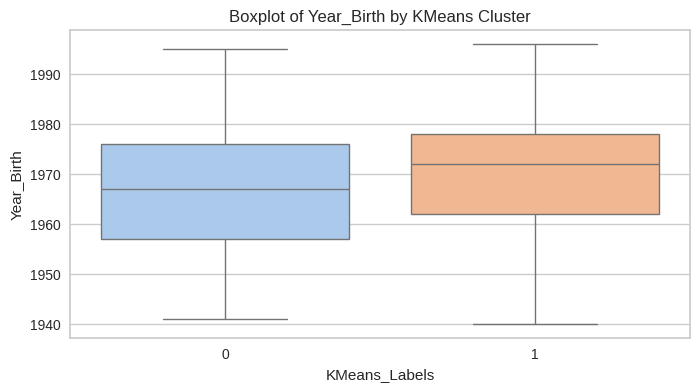

Income
Skew: KMeans_Labels
0    0.42
1    1.48
Name: Income, dtype: float64


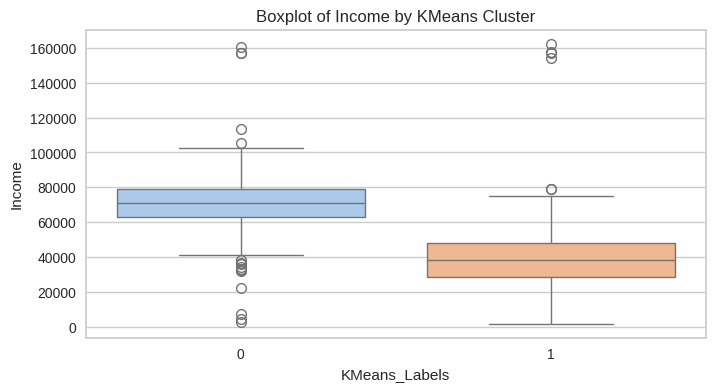

Kidhome
Skew: KMeans_Labels
0    3.78
1   -0.18
Name: Kidhome, dtype: float64


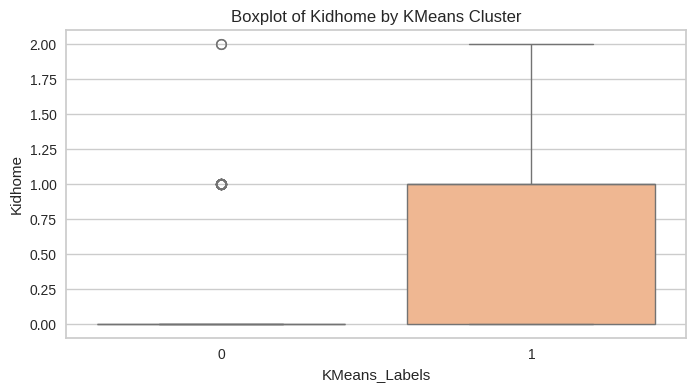

Teenhome
Skew: KMeans_Labels
0    0.62
1    0.26
Name: Teenhome, dtype: float64


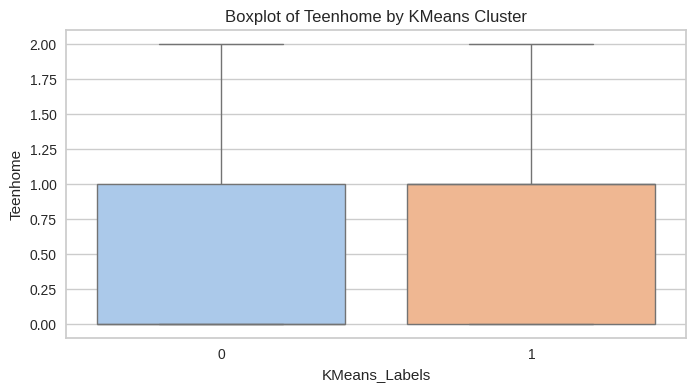

MntWines
Skew: KMeans_Labels
0    0.52
1    2.49
Name: MntWines, dtype: float64


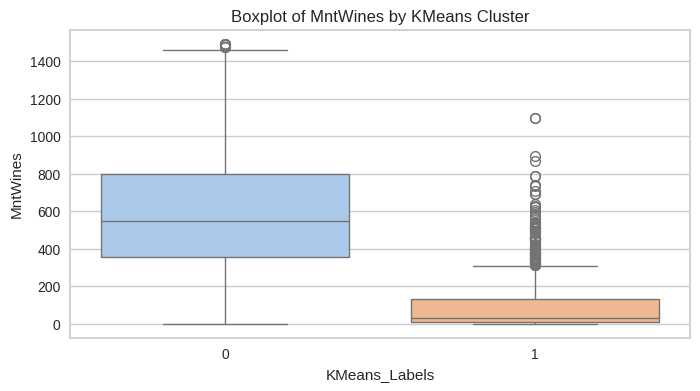

MntFruits
Skew: KMeans_Labels
0    1.05
1    3.12
Name: MntFruits, dtype: float64


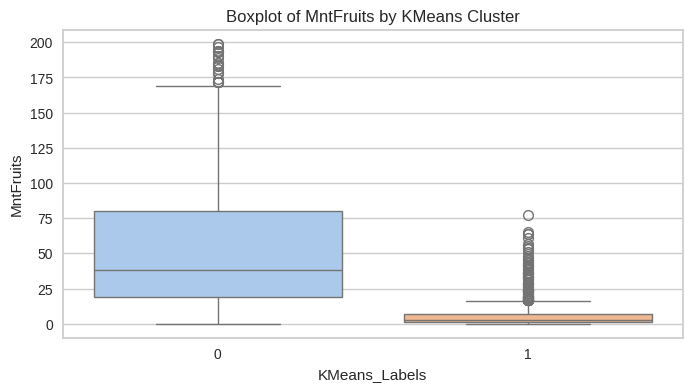

MntMeatProducts
Skew: KMeans_Labels
0    1.37
1    2.16
Name: MntMeatProducts, dtype: float64


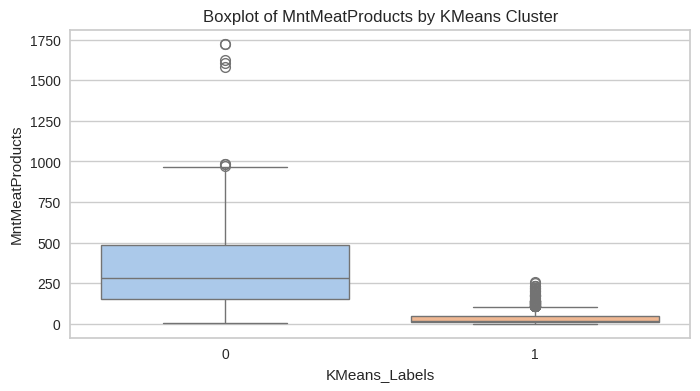

MntFishProducts
Skew: KMeans_Labels
0    0.86
1    4.13
Name: MntFishProducts, dtype: float64


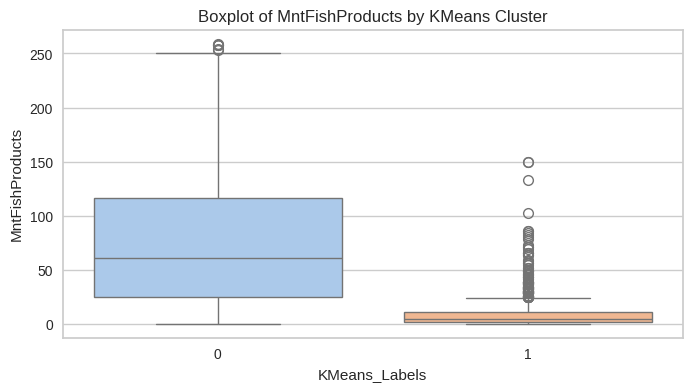

MntSweetProducts
Skew: KMeans_Labels
0    1.07
1    3.66
Name: MntSweetProducts, dtype: float64


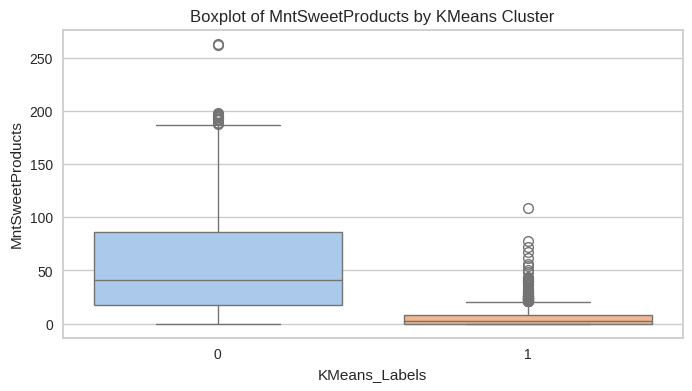

MntGoldProds
Skew: KMeans_Labels
0    1.13
1    3.08
Name: MntGoldProds, dtype: float64


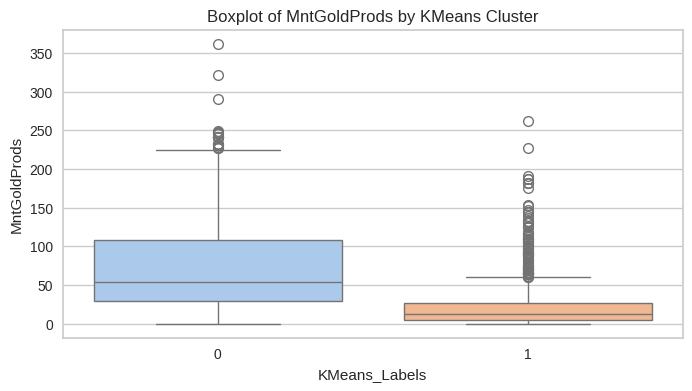

NumDealsPurchases
Skew: KMeans_Labels
0    3.06
1    2.12
Name: NumDealsPurchases, dtype: float64


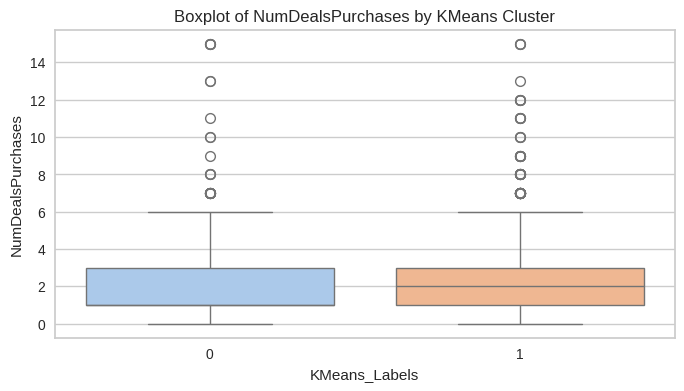

NumWebPurchases
Skew: KMeans_Labels
0    1.93
1    1.25
Name: NumWebPurchases, dtype: float64


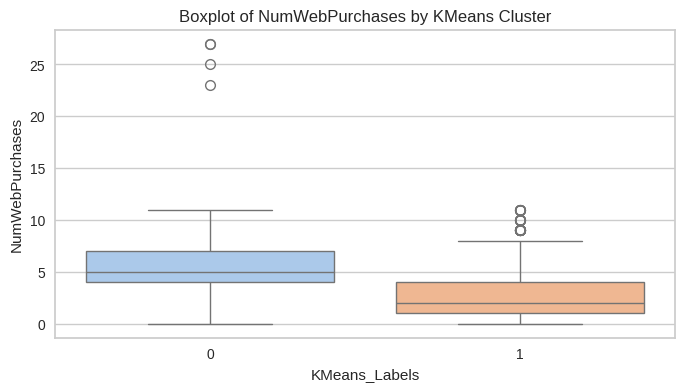

NumCatalogPurchases
Skew: KMeans_Labels
0    2.23
1    1.77
Name: NumCatalogPurchases, dtype: float64


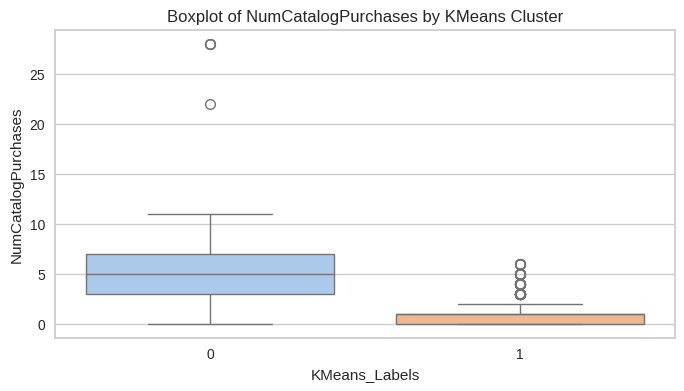

NumStorePurchases
Skew: KMeans_Labels
0   -0.19
1    1.25
Name: NumStorePurchases, dtype: float64


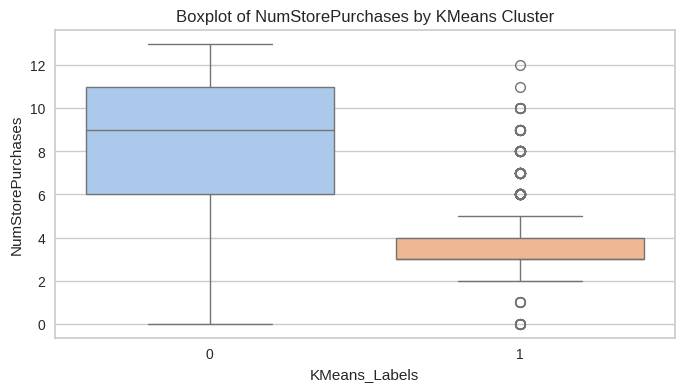

NumWebVisitsMonth
Skew: KMeans_Labels
0    0.45
1    0.92
Name: NumWebVisitsMonth, dtype: float64


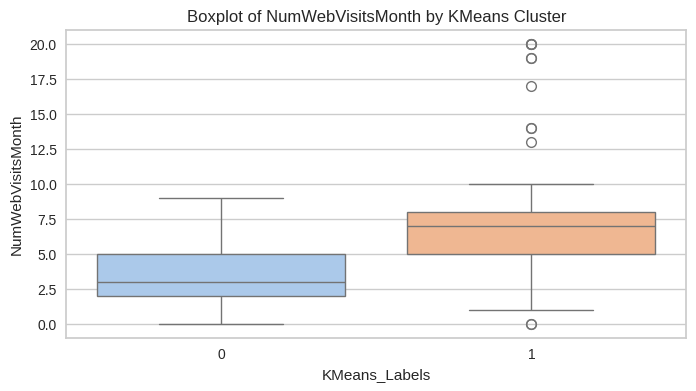

In [ ]:
cols_visualise = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'MntWines', 'MntFruits',
                  'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
                  'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
                  'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
                  'KMeans_Labels']

for col in cols_visualise[:-1]:
    print(col)
    skew_by_cluster = df.groupby('KMeans_Labels')[col].skew()
    print('Skew:', round(skew_by_cluster, 2))
    plt.figure(figsize=(8,4))
    sns.boxplot(x='KMeans_Labels', y=col, data=df, palette='pastel')
    plt.title(f'Boxplot of {col} by KMeans Cluster')
    plt.show()


##### **Observations:**
* `Year_Birth`: **Cluster 0** mainly groups customers born between just before 1960 and around 1975, while **Cluster 1** has customers born from 1960 until the late 1970s. In general, Cluster 0 are slightly older than in Cluster 1.

* `Income`: **Cluster 0**  has a median income around USD 70.000 per year. It has more outliers at the lower end and a few at the higher end. **Cluster 1** has values concentrated between approximately USD 25.000 and 45.000, with a median of USD 40.000 and only a few cstomers with high income outliers.

* `Kidhome` and `Teenhome`: Only two customers have kids at home, and the median of teens at home is 1, in **Cluster 0**. On the other hand, in **Cluster 1**, 50% of customers have 1 kid at home, and 1 teen at home. This is consistent with the distribution. Cluster 0 are older and probably have more teens than young children at home.

* `MntWines` and `MntMeat` : In **Cluster 0**, the amount spent on wine is highest and has fewer outliers with a median of at least 600. In **Cluster 1**, there are many outliers and the median is close to 0. The same happends with meat, Cluster 0 spends more than Cluster 1. The median in Cluster 0 spending on meat is 260, while Cluster 1 it is almost 0.

* `MntFriut`: In **Cluster 1**, the maximum spending on fruits is 75, and the 75% of customers spend around 10 or less. **Cluster 0** has more spends on fruits, with 50% of customers spending between 24 and 76, and the maximum of 200.

* `NumDealsPurchases`: **Cluster 0** uses fewer deals than **Cluster 1**. The median in Cluster 0 is less than 1, and in Cluster 1 the median is 2.

* In all purchases channels, **Cluster 0** has a higher median than **Cluster 1**, so they spend more. Of all the channels, Cluster 0 customers, prefer the store, where the median is 9, higher than in the other channels.

* Although **Cluster 1** makes fewer web purchases than **Cluster 0**, they visit the website much more. The median number of visits per month for Cluster 1 is almost 7.5, while in Cluster 0 the median is just above 2.5.

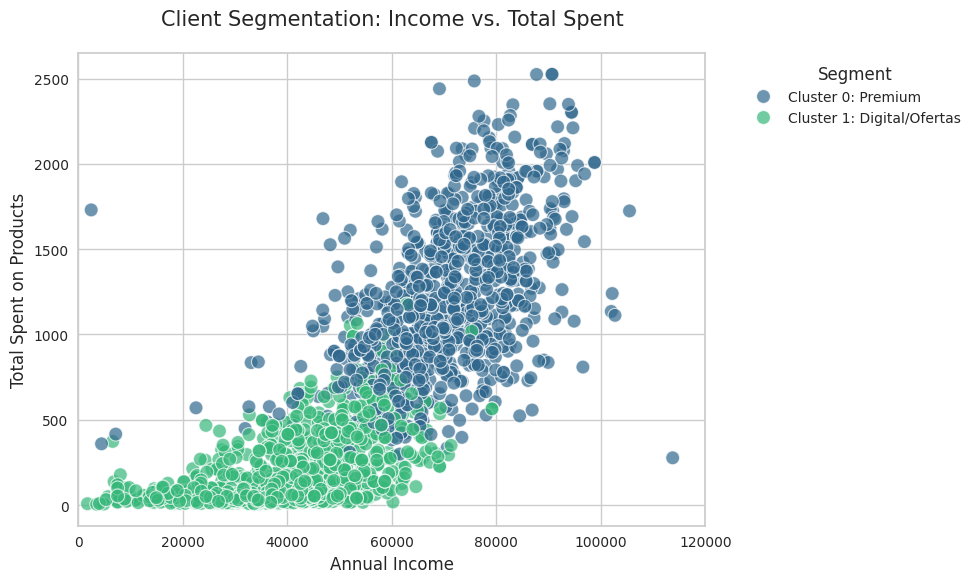

In [ ]:


plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

df['Total_Spent'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

ax = sns.scatterplot(data=df,
                x='Income',
                y='Total_Spent',
                hue='KMeans_Labels',
                palette='viridis',
                s=100,
                alpha=0.7)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles,
          title='Segment',
          labels=['Cluster 0: Premium', 'Cluster 1: Digital/Ofertas'],
          bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 120000)

plt.title('Client Segmentation: Income vs. Total Spent', fontsize=15, pad=20)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Total Spent on Products', fontsize=12)

plt.tight_layout()
plt.show()

#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

Year_Birth
Skew : -0.09


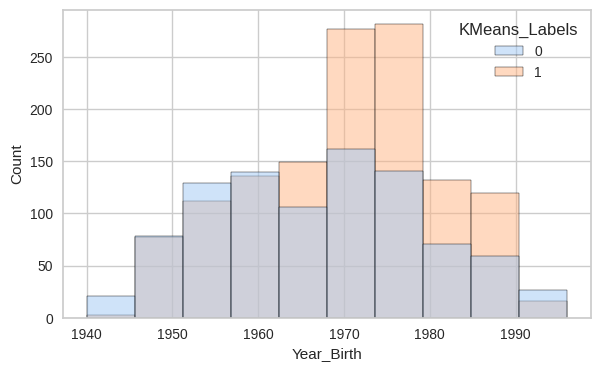

Income
Skew : 0.35


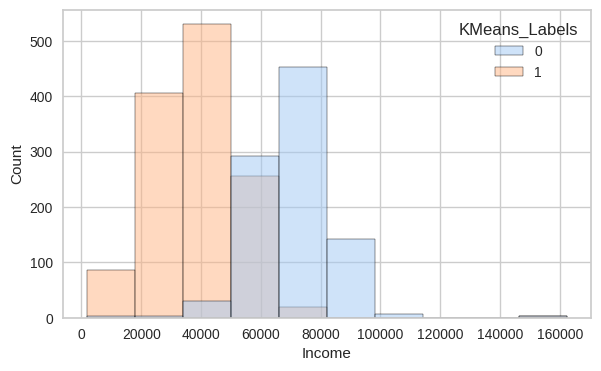

Kidhome
Skew : 0.64


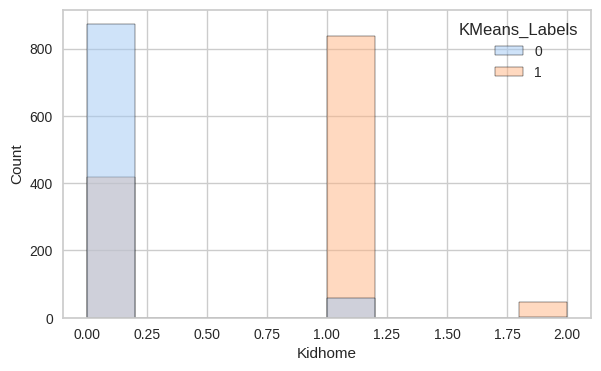

Teenhome
Skew : 0.41


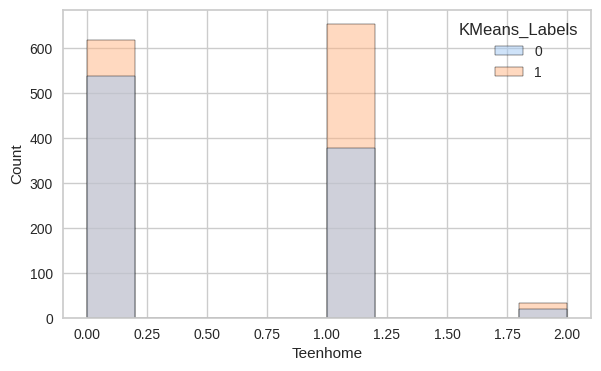

MntWines
Skew : 1.18


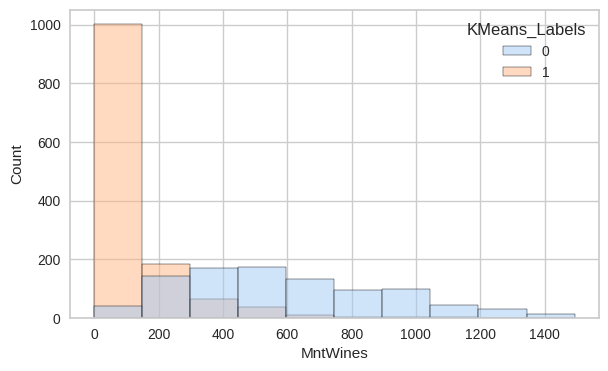

MntFruits
Skew : 2.1


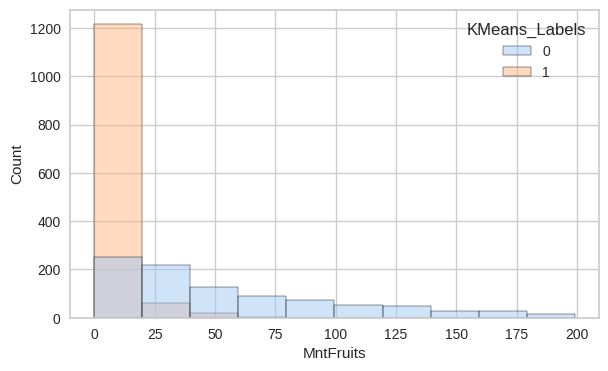

MntMeatProducts
Skew : 2.09


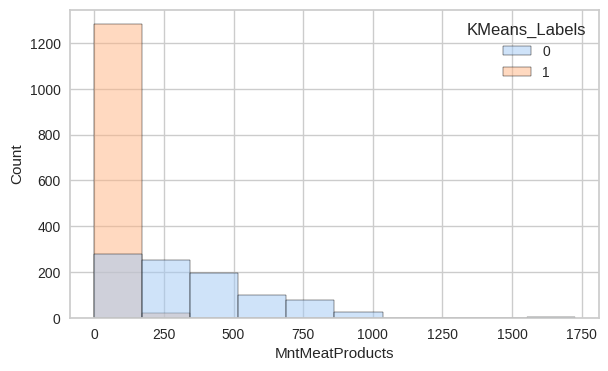

MntFishProducts
Skew : 1.92


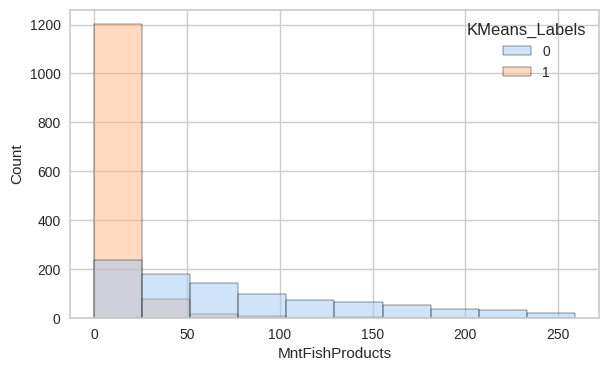

MntSweetProducts
Skew : 2.14


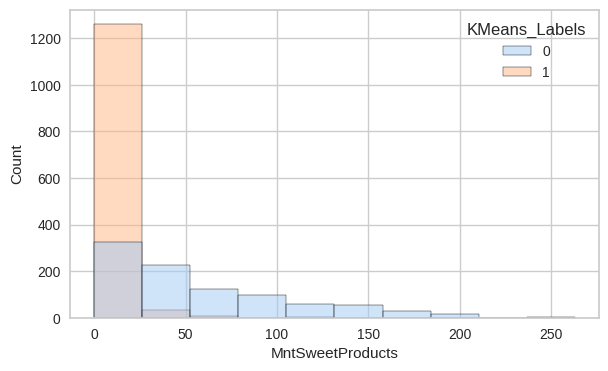

MntGoldProds
Skew : 1.89


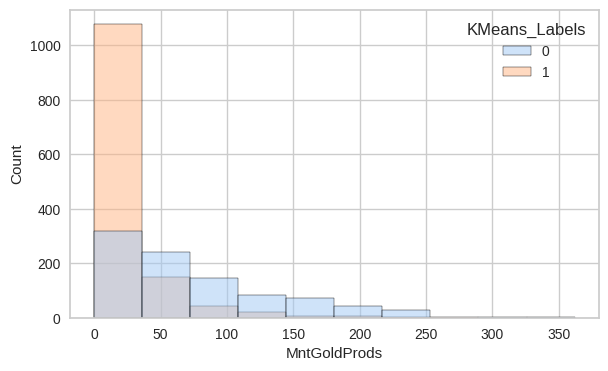

NumDealsPurchases
Skew : 2.42


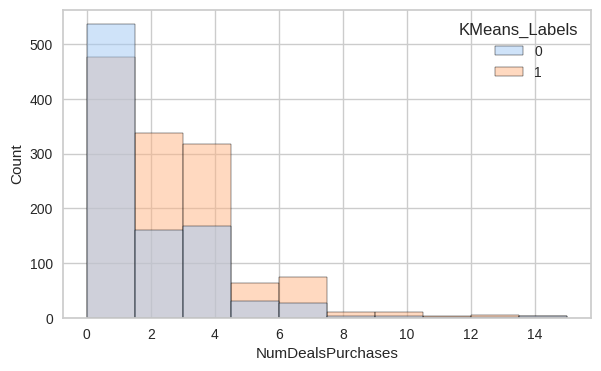

NumWebPurchases
Skew : 1.38


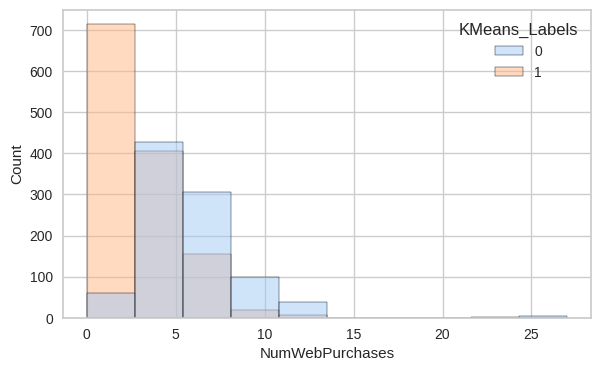

NumCatalogPurchases
Skew : 1.88


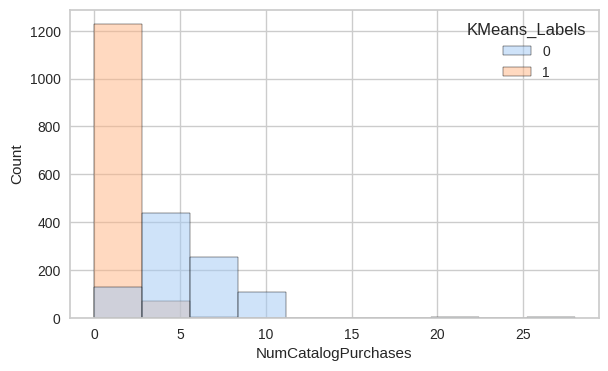

NumStorePurchases
Skew : 0.7


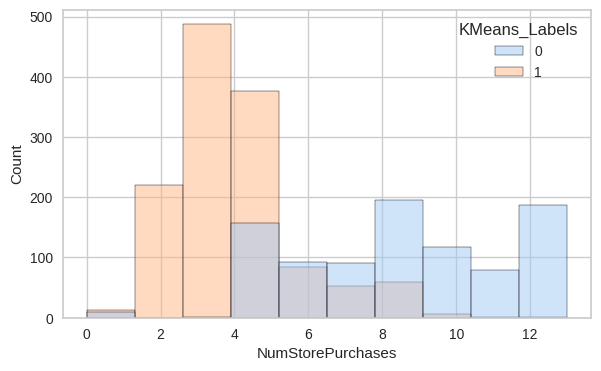

NumWebVisitsMonth
Skew : 0.21


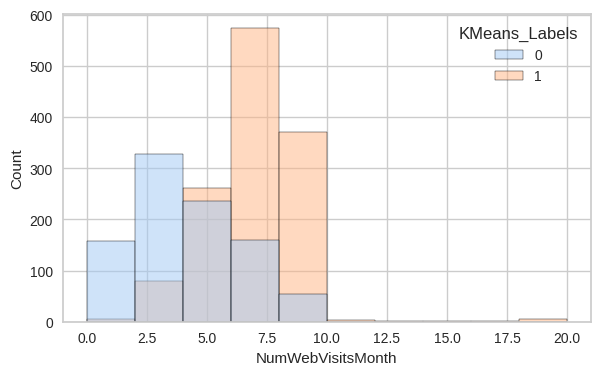

In [ ]:
for col in cols_visualise[:-1]:
    print(col)
    print('Skew :', round(df[col].skew(), 2))

    plt.figure(figsize=(15,4))

    plt.subplot(1,2,1)
    sns.histplot(data=df, x=col, hue='KMeans_Labels', bins=10, palette='pastel', kde=False)
    plt.ylabel('Count')

    plt.show()


##### **Observations:**

Based on the bar charts, we can conclude:

1. `Year_Birth` in Cluster 1 is mainly concentrated between 1970 and 1980, while Cluster 0 is concentrated between 1950 and 1960.

2. The annual income in Cluster 0 is higher than in Cluster 1.

3. In Cluster 0, there are almost no teenagers or children at home, unlike Cluster 1, where most customers have one child and/or one teenager living in the household.

4. The spending across all products is lower in Cluster 1 compared to Cluster 0, while in Cluster 0 the spending is more dispersed.

5. Most customers do not use discounts in their purchases. However, in Cluster 1, a little more than 600 customers make between 2 to 4 discounted purchases, whereas in Cluster 0, only about 300 customers use discounts.

6. Web usage is significantly higher in Cluster 1. However, cluster 0 makes more purchases in all the channels, especially in the store.



**Cluster 0:**
Customers in this group are generally older nd have hicher annual incomes. Most do not have children or teenangers living at home. They spend more across all product categories, particularly on wines and meat. They rarely use discounts and tend to purchase more in store.

**Cluster 1:**
Customers in this group are younger, with lower annual incomes. About the half of them have children or teenangers at home. They spend less overall but uses discounts more frequently. They are more active in the website, with a median of 7.5 visits per month, however, this does not necessarily translate into more purchases.

## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?

**Objectives:**

1. Implement personalized marketing campaigns.

*Cluster 0:*

* Use 2-for-1 promotions on wines in stores instead of standard discounts, which may be more appealing.
* Introduce loyalty points: for example, purchasing meat or wine earns points that can be redeemed for selected products, encouraging cross-product consumption.
* Create product bundles or discounts on selected items, accompanied by in store tasting to encourage purchases. Additionally, offer dish or wine recommendations in small booklets.

*Cluster 1:*

* Provide vouchers and discounts on a variety of products on the website.
* Create a loyalty program: e.g., if they make three or more purchases in a week, they receive a voucher for their next purchase. This could encourage an increase in weekly spending.


2. Retention strategies:

Create a “Plus Benefits Club”: customers can accumulate points (for example, double points) and redeem them for products or free shipping. For these customers:
      1. Allow them to exchange points for gold products.
      2. Offer exclusive discounts on store brands items.
      3. Create special offers on holidays or on customer anniversaries.


3. Optimize resource allocation:

*Cluster 0:*

* Create a dedicated wine and appetizers section near the entrance.

* Use large displays and combo offers along aisles to encourage additional purchases.

*Cluster 1:*

* Organize the online store into clear sections.

* Include a visible offers window and indicate how many purchases are needed to earn benefits.

* Display relevant promotions at checkout to encourage add-on purchases.

* Send frequent product recommendations or app notifications.
